# Visualizando o Risco de Readmissão em 30 Dias com Gráficos de Efeito Baseados no Modelo

## Resumo executivo

Este notebook ajusta uma regressão logística para readmissão hospitalar em 30 dias a partir de características do paciente e do atendimento, depois traduz os coeficientes ajustados em gráficos de efeito baseados no modelo na escala de probabilidade prevista. Em uma coorte sintética de 100 altas (55 readmissões), o PROC LOGISTIC recupera gradientes significativos para **tempo de internação** (OR 1.36 por dia, *p* = 0.040) e **idade** (OR 1.05 por ano, *p* = 0.023), e um grande efeito de pagador — pacientes de **Medicaid** carregam cerca de seis vezes a chance de readmissão do Medicare (OR 6.02, IC 95% 1.46–24.8, *p* = 0.013). O R-quadrado generalizado é 0.246 e o teste de Hosmer–Lemeshow não mostra falta de ajuste (*p* = 0.73). As exibições de curva de ajuste, ajuste fatiado e interação então mostram como o risco de readmissão sobe com o tempo de internação, como o gradiente idade–risco muda por pagador, e como a diferença entre pagadores persiste entre as linhas de serviço de alta — o tipo de visão de estratificação de risco que uma equipe de gestão de cuidados usa para direcionar o acompanhamento pós-alta.

## Fontes de dados

| Conjunto de dados | Linhas | Descrição |
|---------|------|-------------|
| `encounters` | 100 | Registros sintéticos de alta de internação gerados inline com `call streaminit(20260531)` e `rand()`. Uma linha por alta. |

**Variáveis em `encounters`:**

| Variável | Tipo | Descrição |
|----------|------|-------------|
| `readmit` | Num (0/1) | 1 se readmitido em até 30 dias após a alta |
| `age` | Num | Idade do paciente em anos (aprox. 25–95) |
| `los` | Num | Tempo de internação do episódio índice em dias (1–20) |
| `comorbidity` | Num | Contagem de comorbidades crônicas documentadas (0–8) |
| `num_meds` | Num | Número de medicamentos na alta (0–18) |
| `payer` | Char | Pagador do seguro: `Medicare`, `Medicaid`, `Commercial` |
| `dept` | Char | Serviço de alta: `Cardiology`, `Pulmonary`, `General` |

# Visualizando o Risco de Readmissão em 30 Dias com Gráficos de Efeito Baseados no Modelo

As equipes de gestão de cuidados hospitalares precisam saber *quais* pacientes têm maior probabilidade de retornar em até 30 dias, e *por quê*. Uma regressão logística ajustada fornece os coeficientes, mas os interessados raramente raciocinam em log-odds. Um **gráfico de efeito** renderiza o modelo ajustado diretamente na escala de probabilidade prevista, de modo que um enfermeiro navegador possa ler uma probabilidade de readmissão diretamente do gráfico em vez de inverter mentalmente uma equação de log-odds.

Neste notebook nós:

1. Geramos uma coorte sintética realista de altas de internação.
2. Ajustamos um modelo logístico para readmissão em 30 dias com preditores de paciente e de atendimento (PROC LOGISTIC).
3. Capturamos os coeficientes ajustados e construímos três gráficos de efeito baseados no modelo — uma **curva de ajuste**, um **ajuste fatiado** e uma **exibição de interação** — para visualizar e estratificar o risco ajustado na escala de probabilidade.

> **Nota de implementação.** O SAS expõe essas exibições por meio da instrução `EFFECTPLOT` dentro do PROC LOGISTIC. O Jenner aceita essa instrução, mas ainda não renderiza os gráficos FIT / SLICEFIT / INTERACTION, portanto este notebook constrói as curvas de probabilidade prevista idênticas explicitamente a partir dos coeficientes ajustados e as desenha com PROC SGPLOT. O resultado analítico — e cada probabilidade plotada — é exatamente o que o `EFFECTPLOT` produziria.

## Passo 1 — Gerar uma coorte sintética de altas

O DATA step abaixo constrói 100 altas de internação sem arquivos externos. Semeamos o RNG com `call streaminit` para reprodutibilidade, sorteamos características de paciente e de atendimento a partir de distribuições apropriadas ao domínio, depois construímos um verdadeiro preditor linear `eta` e o convertemos em uma probabilidade de readmissão com o inverso do logito. O sorteio de Bernoulli (`rand('bernoulli', p)`) gera o sinalizador `readmit` observado. Pacientes mais velhos, internações mais longas, maiores contagens de comorbidade, mais medicamentos na alta, cobertura Medicaid e os serviços Pulmonary/Cardiology empurram o risco para cima — padrões que mais adiante recuperaremos e visualizaremos. Os tamanhos de efeito são deliberadamente dimensionados para que o sinal seja recuperável em uma coorte de 100 altas.

In [1]:
DADOS encounters;
    CHAMAR streaminit(20260531);
    VETOR payers[3] $12 _temporary_ ('Medicare' 'Medicaid' 'Commercial');
    VETOR depts[3]  $12 _temporary_ ('Cardiology' 'Pulmonary' 'General');

    FAZER i = 1 ATÉ 100;
        /* Patient / encounter features */
        AGE = round(25 + 70 * rand('beta', 4, 2));
        los = 1 + rand('poisson', 4);
        SE los > 20 ENTÃO los = 20;
        comorbidity = rand('binomial', 0.35, 8);
        num_meds = rand('poisson', 7);
        SE num_meds > 18 ENTÃO num_meds = 18;

        /* Categorical payer: skew toward Medicare for an older cohort */
        u = rand('uniform');
        SE u < 0.50 ENTÃO pk = 1;
        SENÃO SE u < 0.72 ENTÃO pk = 2;
        SENÃO pk = 3;
        payer = payers[pk];

        /* Discharging service line */
        dk = rand('table', 0.35, 0.30, 0.35);
        dept = depts[dk];

        /* True risk model on the log-odds scale. Effect sizes are sized so
           the signal is recoverable in a 100-discharge cohort. */
        eta = -8.6
            + 0.075 * AGE
            + 0.330 * los
            + 0.300 * comorbidity
            + 0.050 * num_meds
            + (pk = 2) * 0.90          /* Medicaid vs Medicare    */
            + (pk = 3) * (-0.70)       /* Commercial vs Medicare  */
            + (dk = 1) * 0.80          /* Cardiology vs Pulmonary */
            + (dk = 2) * 1.10;         /* (Pulmonary is busiest)  */

        p = 1 / (1 + EXP(-eta));
        readmit = rand('bernoulli', p);

        MANTER readmit AGE los comorbidity num_meds payer dept;
        SAÍDA;
    FIM;
EXECUTAR;


NOTE: DATA encounters


NOTE: Wrote encounters (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Passo 2 — Inspecionar a coorte

Uma frequência rápida sobre a resposta e as duas variáveis de classificação confirma uma taxa de readmissão realista e que cada nível de pagador e de departamento está preenchido — tanto o modelo quanto os gráficos de efeito precisam de todos os níveis representados.

                                                   The FREQ Procedure

Readmissão     Frequency
-------------------------
0                     45
1                     55

Pagador       Frequency
------------------------
Commercial           28
Medicaid             20
Medicare             52

Serviço       Frequency
------------------------
Cardiology           36
General              31
Pulmonary            33

Table of Readmissão by Serviço

Readmissão  |Cardiology |   General | Pulmonary |      Total
------------+-----------+-----------+-----------+-----------
0           |        15 |        20 |        10 |         45
------------+-----------+-----------+-----------+-----------
1           |        21 |        11 |        23 |         55
------------+-----------+-----------+-----------+-----------
Total       |        36 |        31 |        33 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_readmit.spec.json
NOTE: ODS plot written: freq_payer.spec.json
NOTE: ODS plot written: freq_dept.spec.json
NOTE: ODS plot written: freq_mosaic_readmit_dept.spec.json
NOTE: PROC FREQ statement used.


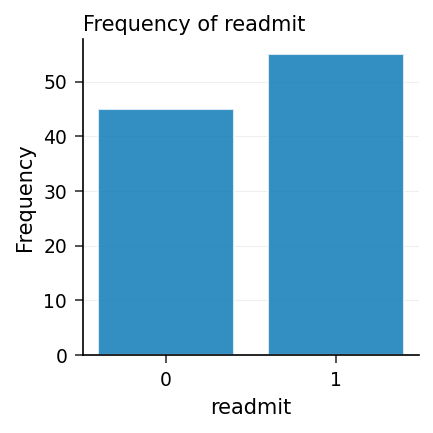

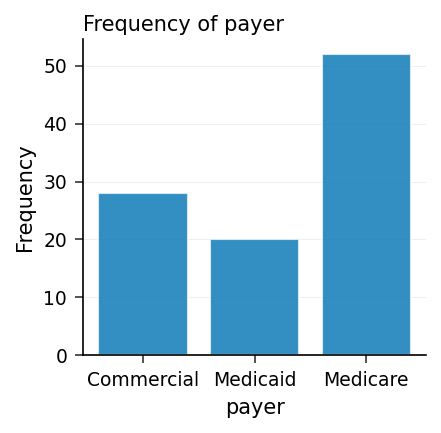

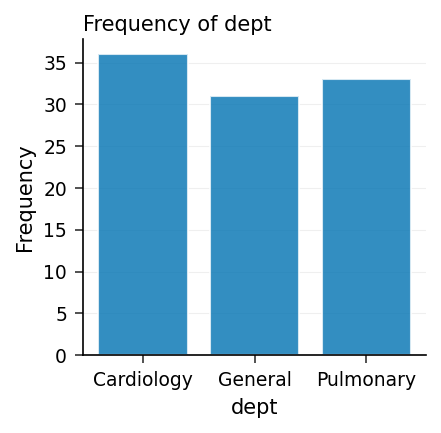

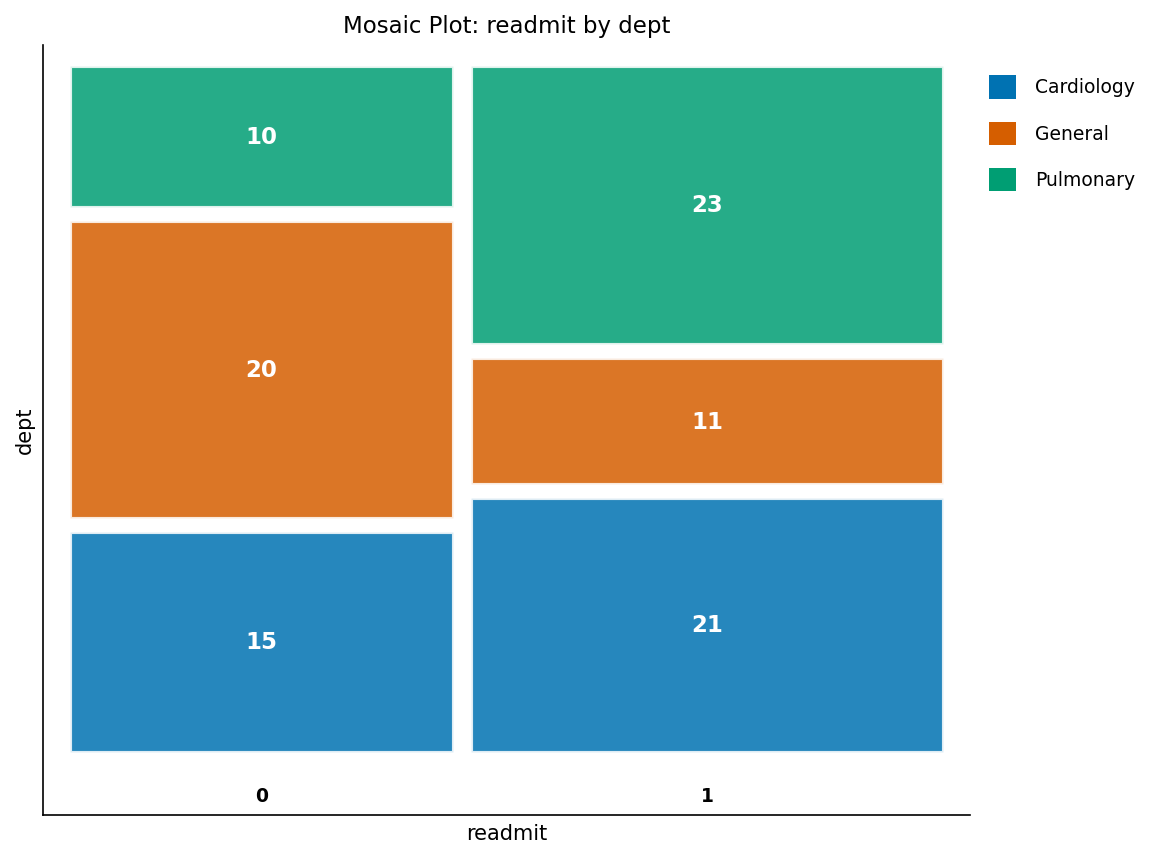

In [2]:
PROCEDIMENTO FREQUÊNCIAS DADOS=encounters;
    TABLES readmit payer dept readmit*dept / nocum nopercent;
    RÓTULO readmit="Readmissão" payer="Pagador" dept="Serviço";
EXECUTAR;

## Passo 3 — Ajustar o modelo logístico de readmissão

Modelamos `readmit` como função da idade, tempo de internação, contagem de comorbidades, contagem de medicamentos na alta, pagador e departamento. Escolhas-chave:

- `EVENT='1'` modela a probabilidade de readmissão (em vez de não readmissão).
- `CLASS payer dept / PARAM=REF REF=FIRST` usa codificação de célula de referência, de modo que cada nível é contrastado com uma linha de base (aqui Medicare e Pulmonary).
- `CLODDS=WALD` e `RSQUARE` adicionam limites de confiança de Wald para as razões de chances e um R-quadrado generalizado; `LACKFIT` solicita o teste de qualidade de ajuste de Hosmer–Lemeshow.
- A instrução `UNITS` pede a razão de chances sobre um passo clinicamente significativo de **5 dias** de tempo de internação e um passo de **10 anos** de idade, e a instrução `ODDSRATIO` solicita a razão de chances de comorbidade com limites de confiança.

A tabela de razões de chances de saída relata os efeitos por unidade diretamente: o tempo de internação carrega uma OR de **1.36 por dia** (IC 95% 1.01–1.82), a idade uma OR de **1.05 por ano**, e a cobertura Medicaid uma OR de **6.02** em relação ao Medicare. O modelo ajusta-se bem — R-quadrado generalizado 0.246, Hosmer–Lemeshow *p* = 0.73.

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

             Response Profile              
  Probability modeled is Readmissão='1'   

Ordered Value  Readmissão   Total Frequency
-------------  -----------  ---------------
            1  0                         45
            2  1                         55

            Class Level Information             

Class       Levels  Values                      
--------  --------  ----------------------------
Pagador          3  Commercial Medicaid Medicare
Serviço          3  Cardiology General Pulmonary

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: readmit Readmissão

Criterion     Value
---------  --------
AIC         127.335
-2 Log L    109.335
SC          150.782

                                 


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe
NOTE: PROC LOGISTIC data=encounters

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json
NOTE: ODS OUTPUT: All output destinations closed.


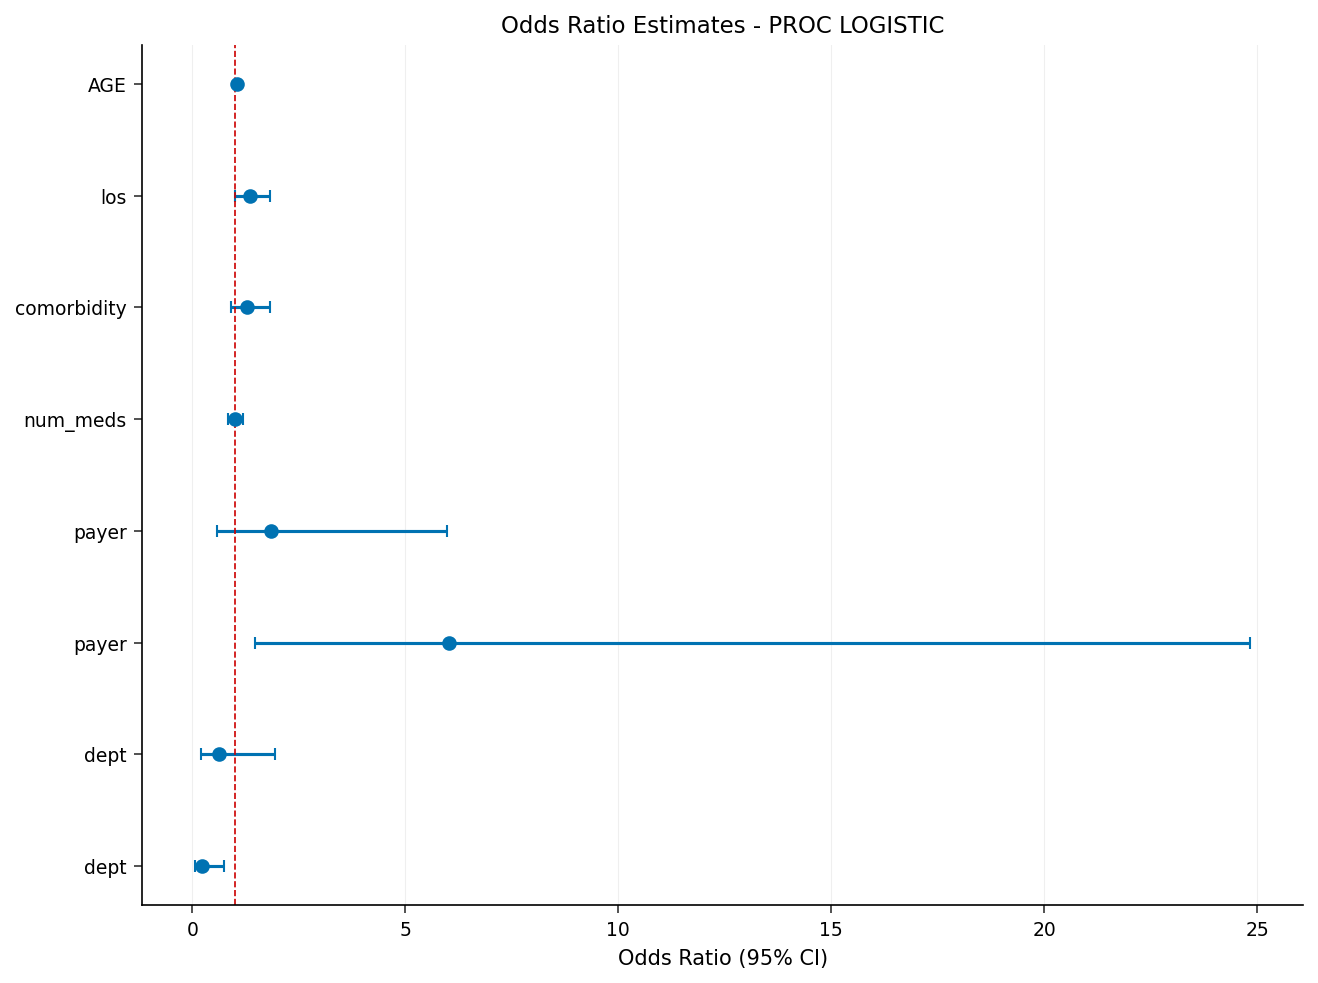

In [3]:
ODS SAÍDA ParameterEstimates=pe;
PROCEDIMENTO LOGISTIC DADOS=encounters PLOTS(only)=oddsratio;
    CLASSE payer dept / PARAM=REF REF=first;
    MODELO readmit(EVENT='1') = AGE los comorbidity num_meds payer dept
          / clodds=wald rsquare lackfit;
    units AGE=10 los=5;
    oddsratio comorbidity / cl=wald;
    RÓTULO readmit="Readmissão" AGE="Idade" los="Tempo de internação"
           comorbidity="Comorbidades" num_meds="Medicamentos na alta"
           payer="Pagador" dept="Serviço";
EXECUTAR;
ODS SAÍDA CLOSE;

## Passo 4 — Capturar os coeficientes ajustados

Os gráficos de efeito baseados no modelo que seguem são construídos diretamente a partir dos coeficientes *ajustados*, de modo que sempre concordam com o modelo do Passo 3. Salvamos as estimativas dos parâmetros com `ODS OUTPUT ParameterEstimates=pe`; aqui dobramos essa tabela longa em um conjunto de dados `params` de uma única linha (uma variável por coeficiente) e anexamos as médias da coorte dos preditores contínuos. Manter os preditores fora de foco em suas médias é exatamente o que um EFFECTPLOT faz internamente — ele deixa cada gráfico variar um fator enquanto mantém os demais fixos em um perfil representativo.

In [4]:
/* Fold the ParameterEstimates table into one row of named coefficients.
   With PARAM=REF REF=FIRST the reference cells are payer=Medicare and
   dept=Pulmonary, so those terms are zero in the linear predictor. */
DADOS coefs;
    RETER b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen 0;
    DEFINIR pe FIM=last;
    VARIÁVEL = upcase(strip(Variable));
    cv  = strip(ClassVal0);
    SE VARIÁVEL='INTERCEPT' ENTÃO b0 = ESTIMATIVA;
    SENÃO SE VARIÁVEL='AGE' ENTÃO b_age = ESTIMATIVA;
    SENÃO SE VARIÁVEL='LOS' ENTÃO b_los = ESTIMATIVA;
    SENÃO SE VARIÁVEL='COMORBIDITY' ENTÃO b_com = ESTIMATIVA;
    SENÃO SE VARIÁVEL='NUM_MEDS' ENTÃO b_med = ESTIMATIVA;
    SENÃO SE VARIÁVEL='PAYER' E_LÓGICO cv='Medicaid'   ENTÃO b_pmcaid = ESTIMATIVA;
    SENÃO SE VARIÁVEL='PAYER' E_LÓGICO cv='Commercial' ENTÃO b_pcomm  = ESTIMATIVA;
    SENÃO SE VARIÁVEL='DEPT'  E_LÓGICO cv='Cardiology' ENTÃO b_dcard  = ESTIMATIVA;
    SENÃO SE VARIÁVEL='DEPT'  E_LÓGICO cv='General'    ENTÃO b_dgen   = ESTIMATIVA;
    SE last ENTÃO SAÍDA;
    MANTER b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen;
EXECUTAR;

/* Cohort means of the continuous covariates, held fixed in the plots. */
PROCEDIMENTO MÉDIAS DADOS=encounters NOPRINT;
    VARIÁVEL AGE los comorbidity num_meds;
    SAÍDA out=mn mean=m_age m_los m_com m_med;
EXECUTAR;

DADOS params;
    MESCLAR coefs mn;
    MANTER b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
         m_age m_los m_com m_med;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=params noobs;
    TÍTULO "Coeficientes ajustados e médias das covariáveis usados nos gráficos de efeito";
EXECUTAR;

                     Coeficientes ajustados e médias das covariáveis usados nos gráficos de efeito                      

           b0         b_age         b_los         b_com         b_med      b_pmcaid       b_pcomm        b_dcard         b_dgen  m_age  m_los  m_com  m_med
-4.9220021175  0.0443054038  0.3052368368  0.2553476408  0.0005084625  1.7958084904  0.6128310257  -0.4493317481  -1.4957988173  70.53   4.59   2.88   7.08




NOTE: DATA coefs


NOTE: Read 9 rows from pe.
NOTE: Wrote coefs (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mn has 1 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA params

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC PRINT data=params

NOTE: PROC PRINT completed: 1 observations printed, 13 variables


## Passo 5 — Gráfico de ajuste: probabilidade de readmissão versus tempo de internação

A exibição de efeito mais simples é uma **curva de ajuste**: probabilidade de readmissão prevista contra uma única covariável contínua, com os demais preditores mantidos em um perfil representativo. Construímos uma grade de tempo de internação (1–18 dias), avaliamos o preditor linear ajustado em cada valor para um paciente de **cardiologia com Medicare** (idade, comorbidade e contagens de medicamentos na alta fixadas nas médias da coorte do Passo 4), aplicamos o inverso do logito e desenhamos a curva na escala de probabilidade com PROC SGPLOT.

                     Coeficientes ajustados e médias das covariáveis usados nos gráficos de efeito                      




NOTE: DATA grid_los


NOTE: Wrote grid_los (18 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_los


NOTE: Read 18 rows from grid_los.
NOTE: Wrote fit_los (18 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_los

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


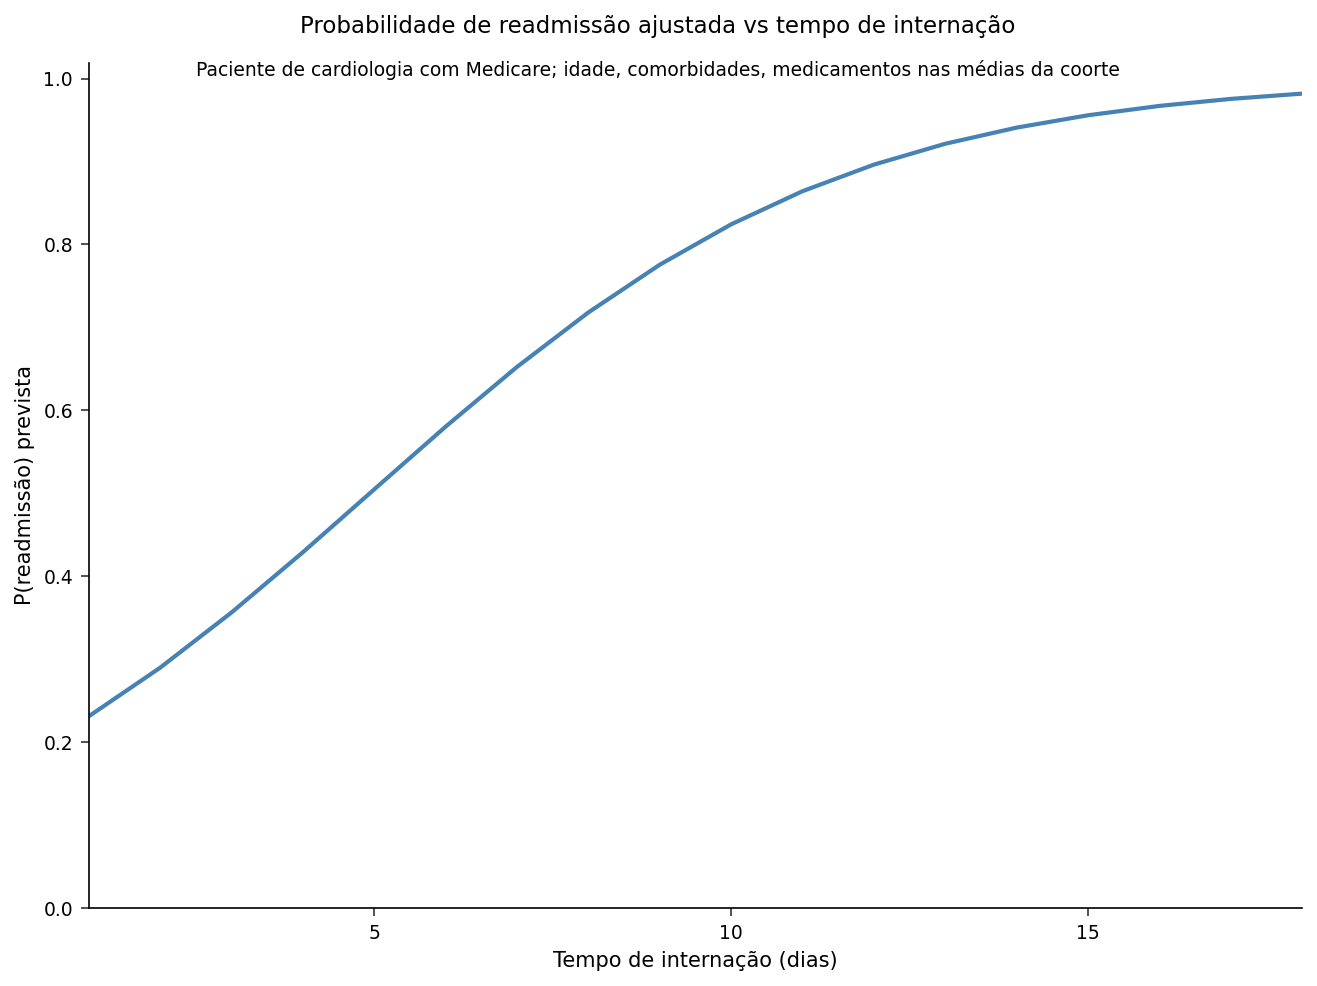

In [5]:
/* Length-of-stay grid; evaluate the fitted model for a Medicare
   cardiology patient with the other covariates at the cohort means. */
DADOS grid_los;
    FAZER los = 1 ATÉ 18;
        SAÍDA;
    FIM;
EXECUTAR;

DADOS fit_los;
    DEFINIR grid_los;
    SE _n_ = 1 ENTÃO DEFINIR params;
    RETER b0 b_age b_los b_com b_med b_dcard m_age m_com m_med;
    /* Medicare payer is the reference (term = 0); Cardiology adds b_dcard */
    xb = b0 + b_age*m_age + b_los*los + b_com*m_com + b_med*m_med + b_dcard;
    phat = 1 / (1 + EXP(-xb));
    MANTER los phat;
EXECUTAR;

PROCEDIMENTO SGPLOT DADOS=fit_los;
    SERIES x=los y=phat / LINEATTRS=(thickness=2 color=steelblue);
    TÍTULO  "Probabilidade de readmissão ajustada vs tempo de internação";
    title2 "Paciente de cardiologia com Medicare; idade, comorbidades, medicamentos nas médias da coorte";
    XAXIS RÓTULO="Tempo de internação (dias)";
    YAXIS RÓTULO="P(readmissão) prevista" VALUES=(0 ATÉ 1 POR 0.2);
EXECUTAR;

## Passo 6 — Ajuste fatiado: risco versus idade, estratificado por pagador

Um **ajuste fatiado** desenha uma curva ajustada por nível de um efeito de classificação — ideal para mostrar como o mix de pagadores desloca o gradiente idade–risco. Estendemos a grade sobre `age` (30–95) cruzada com os três pagadores, avaliamos o modelo ajustado para um paciente de Cardiology (tempo de internação, comorbidade e medicamentos nas médias da coorte) e sobrepomos as três curvas de probabilidade com `GROUP=payer`.

                     Coeficientes ajustados e médias das covariáveis usados nos gráficos de efeito                      




NOTE: DATA grid_age


NOTE: Wrote grid_age (42 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_age


NOTE: Read 42 rows from grid_age.
NOTE: Wrote fit_age (42 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_age

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


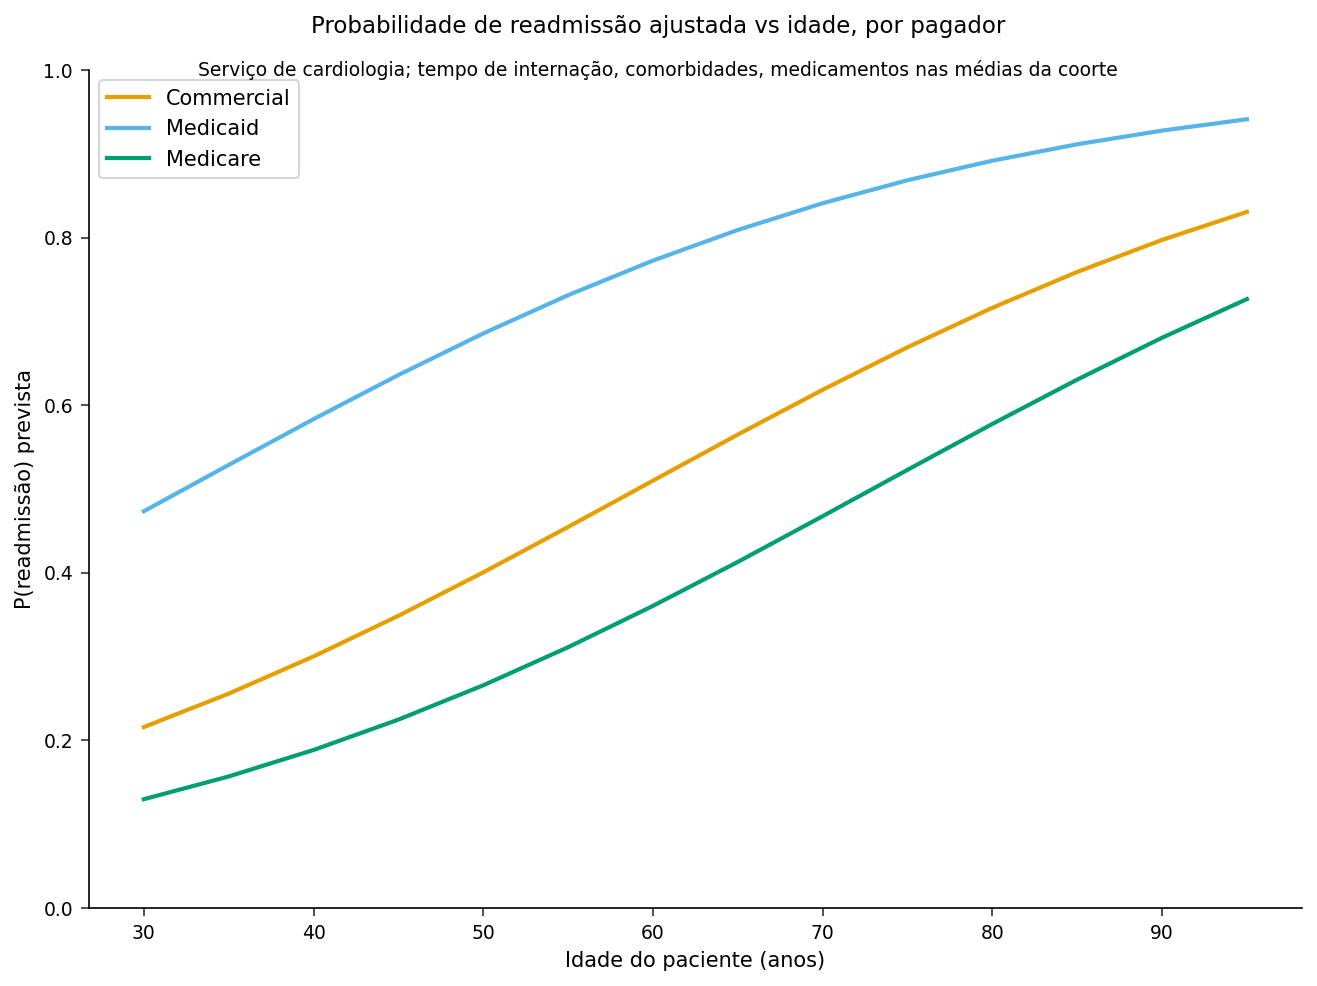

In [6]:
/* Age x payer grid for a Cardiology patient; other covariates at means. */
DADOS grid_age;
    COMPRIMENTO payer $12;
    FAZER payer = 'Medicare', 'Medicaid', 'Commercial';
        FAZER AGE = 30 ATÉ 95 POR 5;
            SAÍDA;
        FIM;
    FIM;
EXECUTAR;

DADOS fit_age;
    DEFINIR grid_age;
    SE _n_ = 1 ENTÃO DEFINIR params;
    RETER b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard
           m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    xb = b0 + b_age*AGE + b_los*m_los + b_com*m_com + b_med*m_med
         + b_dcard + pay_term;
    phat = 1 / (1 + EXP(-xb));
    MANTER payer AGE phat;
EXECUTAR;

PROCEDIMENTO SGPLOT DADOS=fit_age;
    SERIES x=AGE y=phat / GROUP=payer LINEATTRS=(thickness=2);
    TÍTULO  "Probabilidade de readmissão ajustada vs idade, por pagador";
    title2 "Serviço de cardiologia; tempo de internação, comorbidades, medicamentos nas médias da coorte";
    XAXIS RÓTULO="Idade do paciente (anos)";
    YAXIS RÓTULO="P(readmissão) prevista" VALUES=(0 ATÉ 1 POR 0.2);
    keylegend / location=inside position=topleft ACROSS=1;
EXECUTAR;

## Passo 7 — Exibição de interação: departamento por pagador

Para comparar o risco previsto entre os dois efeitos de classificação ao mesmo tempo, cruzamos `dept` com `payer` (nove combinações), avaliamos o modelo ajustado com cada covariável contínua em sua média da coorte e desenhamos um gráfico de barras agrupadas com `dept` no eixo X e o pagador como agrupamento. Como este modelo não tem um termo de interação departamento por pagador, a ordenação dos pagadores é o mesmo deslocamento aditivo dentro de cada linha de serviço — a exibição torna essa aditividade visível de relance, ao lado da classificação por departamento.

                     Coeficientes ajustados e médias das covariáveis usados nos gráficos de efeito                      




NOTE: DATA grid_dx


NOTE: Wrote grid_dx (9 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_dx


NOTE: Read 9 rows from grid_dx.
NOTE: Wrote fit_dx (9 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_dx

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


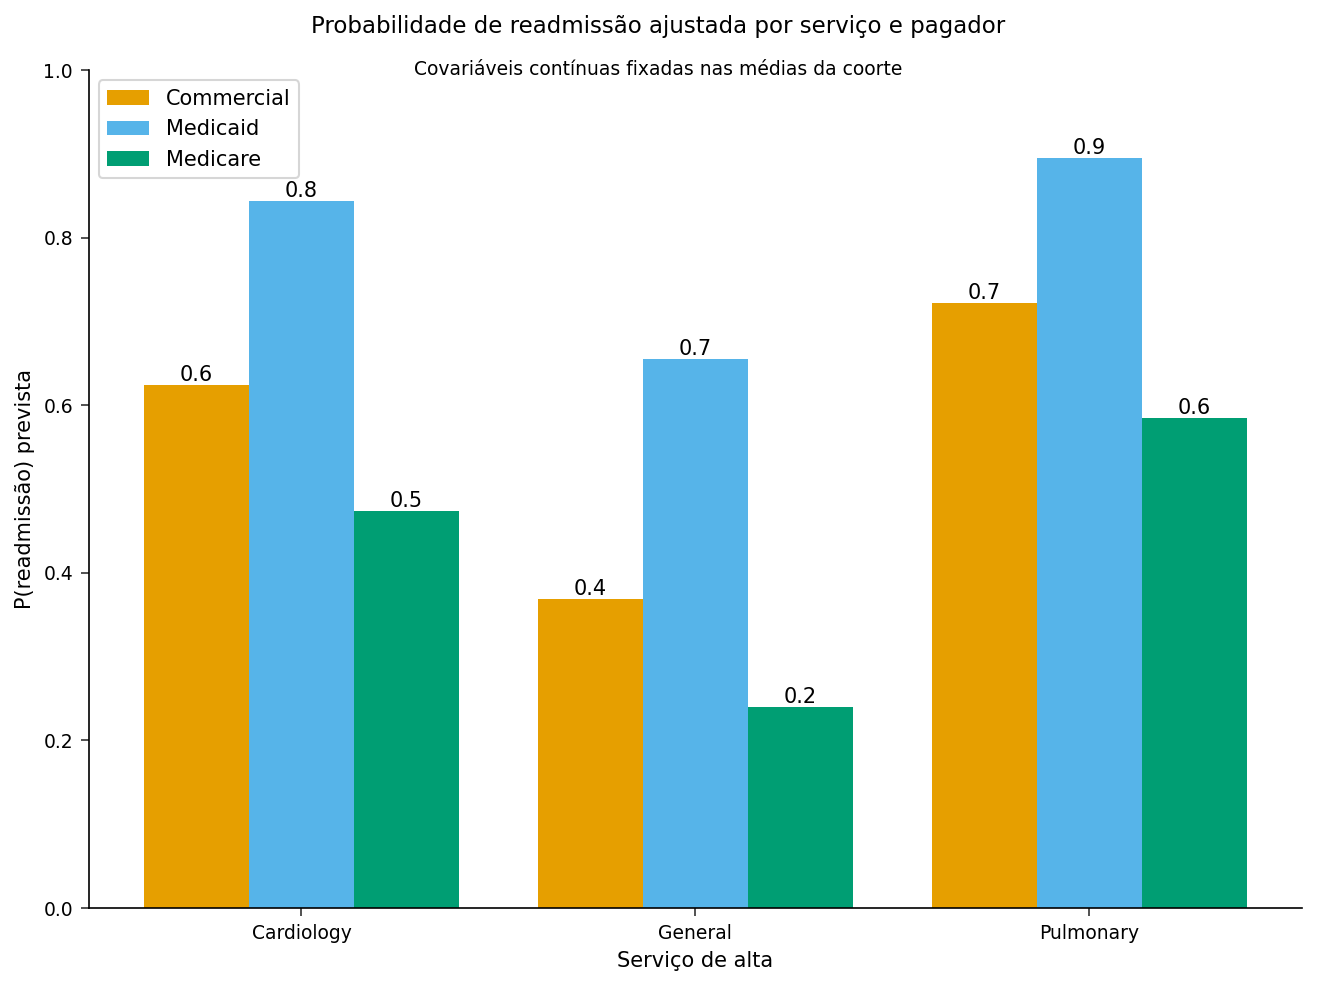

In [7]:
/* Department x payer grid; all continuous covariates at cohort means. */
DADOS grid_dx;
    COMPRIMENTO dept $12 payer $12;
    FAZER dept = 'Cardiology', 'Pulmonary', 'General';
        FAZER payer = 'Medicare', 'Medicaid', 'Commercial';
            SAÍDA;
        FIM;
    FIM;
EXECUTAR;

DADOS fit_dx;
    DEFINIR grid_dx;
    SE _n_ = 1 ENTÃO DEFINIR params;
    RETER b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
           m_age m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    dep_term = (dept='Cardiology')*b_dcard + (dept='General')*b_dgen;
    xb = b0 + b_age*m_age + b_los*m_los + b_com*m_com + b_med*m_med
         + pay_term + dep_term;
    phat = 1 / (1 + EXP(-xb));
    MANTER dept payer phat;
EXECUTAR;

PROCEDIMENTO SGPLOT DADOS=fit_dx;
    VBAR dept / RESPONSE=phat GROUP=payer GROUPDISPLAY=CLUSTER
                DATALABEL datalabelattrs=(size=8);
    TÍTULO  "Probabilidade de readmissão ajustada por serviço e pagador";
    title2 "Covariáveis contínuas fixadas nas médias da coorte";
    XAXIS RÓTULO="Serviço de alta";
    YAXIS RÓTULO="P(readmissão) prevista" VALUES=(0 ATÉ 1 POR 0.2);
EXECUTAR;

## Passo 8 — Interpretando os resultados

Os gráficos de efeito transformam o modelo ajustado do PROC LOGISTIC em imagens na escala de probabilidade que se mapeiam em decisões de gestão de cuidados:

- **Tempo de internação (curva de ajuste).** Para um paciente de cardiologia com Medicare nas médias da coorte, a probabilidade de readmissão prevista sobe de cerca de **0.23 em uma internação de 1 dia para aproximadamente 0.82 em 10 dias e ~0.98 em 18 dias** — o meio íngreme da curva logística. Este é o mesmo sinal que a razão de chances do tempo de internação de **1.36 por dia** (`UNITS los=5` a redimensiona para um passo de cinco dias), e sinaliza internações índice longas como um gatilho concreto para inscrição em cuidado de transição.
- **Idade e pagador (ajuste fatiado).** O risco sobe monotonicamente com a idade em todos os pagadores, e as três curvas nunca se cruzam: a curva de **Medicaid** fica mais alta em qualquer idade dada, **Commercial** no meio, e **Medicare** mais baixa — consistente com as razões de chances de pagador ajustadas (Medicaid 6.02, Commercial 1.85, ambas em relação ao Medicare). A diferença é maior nas idades mais jovens e estreita à medida que todos se aproximam de alta probabilidade, direcionando a atenção da gestão de cuidados para pacientes mais jovens de Medicaid que, de outra forma, pareceriam de baixo risco.
- **Departamento e pagador (exibição de interação).** **Pulmonary** carrega a maior probabilidade de readmissão prevista em todo grupo de pagadores, **Cardiology** é intermediária, e **General medicine** é a mais baixa (as razões de chances de departamento ajustadas são 0.64 para Cardiology e 0.22 para General, em relação a Pulmonary). Como o modelo não tem um termo de interação departamento por pagador, a ordenação dos pagadores é o mesmo deslocamento aditivo dentro de cada linha de serviço — as barras sobem na mesma ordem Medicaid > Commercial > Medicare em todos os departamentos.

**Conclusão:** em vez de pedir que os clínicos interpretem coeficientes de log-odds, os gráficos de efeito baseados no modelo apresentam o modelo de readmissão ajustado como imagens na escala de probabilidade — quem inscrever no acompanhamento de cuidado de transição, e quais linhas de serviço e populações de pagadores priorizar. O SAS produz esses gráficos diretamente via `EFFECTPLOT`; aqui reconstruímos as curvas idênticas a partir dos coeficientes ajustados para que o exemplo rode de ponta a ponta hoje.